# Flat Polynomials — Analysis & Verification

This notebook verifies our solution for the **flat polynomials** problem (Einstein Arena slug `flat-polynomials`).

**Problem:** Choose coefficients $c_0,\ldots,c_{69} \in \{\pm 1\}$ for $g(z) = c_0 z^{69} + \cdots + c_{69}$ to minimize
$$C^+ = \frac{\max_{|z|=1} |g(z)|}{\sqrt{71}}.$$
The server evaluates $|g(z)|$ at $10^6$ equally spaced points on the unit circle (`np.poly1d` ordering: first coefficient $\times z^{69}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, "solutions")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## 1. Verification function

Exact **Einstein Arena** verifier (copied from `einstein-arena/web/src/lib/problems/flat-polynomials.ts`):

In [2]:
def evaluate(data):
    coefficients = np.array(data["coefficients"], dtype=np.float64)
    assert len(coefficients) == 70, f"Expected 70 coefficients, got {len(coefficients)}"
    assert all(c in (-1, 1) for c in coefficients), "All coefficients must be +1 or -1"
    poly_fn = np.poly1d(coefficients)
    num_points = 1_000_000
    zs = np.exp(1j * np.linspace(0, 2 * np.pi, num_points))
    vals = np.abs(poly_fn(zs))
    return float(np.max(vals) / np.sqrt(len(coefficients) + 1))

## 2. Load solutions

In [3]:
from alphaevolve_2025 import coefficients as c_ae
from ours_2026 import coefficients as c_ours

payloads = [
    ("AlphaEvolve V2 (Georgiev et al., baseline)", {"coefficients": c_ae.tolist()}),
    ("Ours (2026)", {"coefficients": c_ours.tolist()}),
]

for name, data in payloads:
    c = np.array(data["coefficients"], dtype=np.int8)
    print(
        f"{name}: {len(c)} coeffs, unique {{+1, -1}}, "
        f"sum={int(c.sum())}"
    )

AlphaEvolve V2 (Georgiev et al., baseline): 70 coeffs, unique {+1, -1}, sum=-6
Ours (2026): 70 coeffs, unique {+1, -1}, sum=4


## 3. Verify score

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS (Einstein Arena `evaluate`)")
print("=" * 70)
print()

scores = {}
for name, data in payloads:
    score = evaluate(data)
    scores[name] = score
    print(f"{name}")
    print(f"  C+ = {score:.15f}")
    print()

print("=" * 70)
print("COMPARISON (lower C+ is better)")
print("=" * 70)
for name, data in payloads:
    print(f"{name:<45} {scores[name]:.15f}")

VERIFICATION OF ALL SOLUTIONS (Einstein Arena `evaluate`)

AlphaEvolve V2 (Georgiev et al., baseline)
  C+ = 1.340925279455708

Ours (2026)
  C+ = 1.280932052798800

COMPARISON (lower C+ is better)
AlphaEvolve V2 (Georgiev et al., baseline)    1.340925279455708
Ours (2026)                                   1.280932052798800


## 4. Visualization

Modulus $|g(e^{i\theta})|$ on a dense grid (plotting uses fewer samples than the verifier for speed).

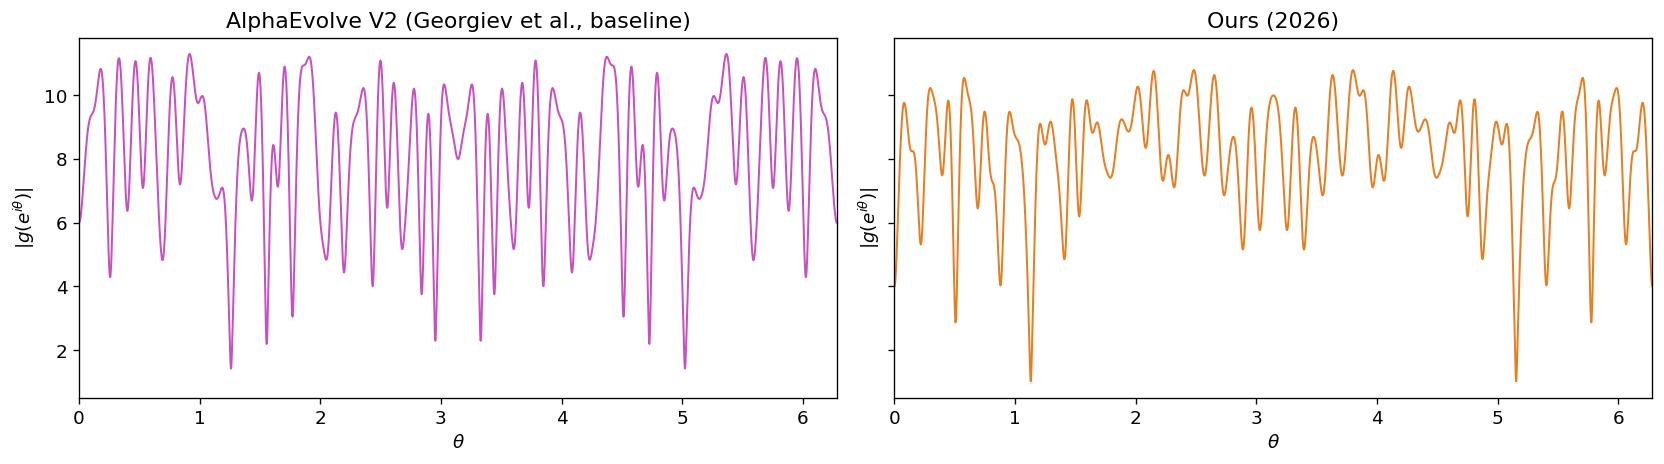

In [5]:
thetas = np.linspace(0, 2 * np.pi, 4000, endpoint=False)
z = np.exp(1j * thetas)
colors = ["#C850C0", "#E67E22"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, ((name, data), color) in zip(axes, zip(payloads, colors)):
    c = np.array(data["coefficients"], dtype=np.float64)
    p = np.poly1d(c)
    mag = np.abs(p(z))
    ax.plot(thetas, mag, color=color, lw=1.2)
    ax.set_title(name)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$|g(e^{i\theta})|$")
    ax.set_xlim(0, 2 * np.pi)
plt.tight_layout()
plt.show()